In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer   
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report, accuracy_score

# deep learning ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


import warnings
warnings.filterwarnings('ignore')

# Reproducibility helps you get similar
# results across runs 
np.random.seed(42)



In [2]:
import sklearn
print(np.__version__)
print(pd.__version__)
print(tf.__version__)
print(sklearn.__version__)


2.3.5
2.3.3
2.21.0
1.8.0


In [3]:
# loading the data ...
df = pd.read_csv(r"C:\Users\suman\Downloads\DL\Project on ANN\Apartment_Rent_Dataset - LMS.csv")
df.head()

,listing_id,city,locality,property_type,bhk,bathrooms,builtup_sqft,carpet_area_sqft,floor_number,total_floors,building_age_years,furnishing,parking_slots,gated_society,amenities_score,metro_distance_km,commute_time_to_business_district_min,maintenance_included,power_backup,monthly_rent_inr
0,HSG-966691-04078,Bengaluru,Yelahanka,Apartment,3,3,978,848.0,5,8,14,Unfurnished,1.0,0,48.0,NaN,119,Yes,Partial,36440
1,HSG-637024-04132,Chennai,Porur,Builder Floor,2,3,460,411.0,1,4,16,Fully Furnished,1.0,1,53.0,1.56,58,No,Partial,11380
2,OLX-835407-07415,Surat,Pal,Apartment,3,4,1253,904.0,3,10,5,Semi-Furnished,1.0,0,61.0,NaN,40,No,Partial,55370
3,MB-833530-07023,Pune,Hadapsar,Apartment,3,4,906,717.0,4,12,6,Semi-Furnished,2.0,1,70.0,3.61,95,No,Full,51750
4,HSG-716103-05993,Bhubaneswar,Gajapati Nagar,Builder Floor,2,3,757,611.0,0,3,10,Unfurnished,1.0,1,51.0,NaN,77,No,Partial,10290


In [4]:
# Basic dataset Inspection ...
print(" Shape: ", df.shape)
print("/n Columns:", list(df.columns))
display(df.sample(5,random_state=42))

 Shape:  (9458, 20)
/n Columns: ['listing_id', 'city', 'locality', 'property_type', 'bhk', 'bathrooms', 'builtup_sqft', 'carpet_area_sqft', 'floor_number', 'total_floors', 'building_age_years', 'furnishing', 'parking_slots', 'gated_society', 'amenities_score', 'metro_distance_km', 'commute_time_to_business_district_min', 'maintenance_included', 'power_backup', 'monthly_rent_inr']


,listing_id,city,locality,property_type,bhk,bathrooms,builtup_sqft,carpet_area_sqft,floor_number,total_floors,building_age_years,furnishing,parking_slots,gated_society,amenities_score,metro_distance_km,commute_time_to_business_district_min,maintenance_included,power_backup,monthly_rent_inr
4078,99A-224753-01620,Delhi,Janakpuri,Apartment,3,4,1045,866.0,1,19,17,Unfurnished,0.0,1,52.0,NaN,68,Yes,Partial,32890
4132,HSG-958230-04348,Kolkata,Ballygunge,Apartment,3,4,1312,1069.0,13,16,36,Unfurnished,1.0,0,30.0,2.54,43,No,NaN,40060
7415,NB-105997-06441,Bhubaneswar,Nayapalli,Apartment,2,2,739,593.0,7,18,1,Unfurnished,1.0,1,NaN,NaN,75,Yes,Full,17460
7023,99A-883755-07902,Nashik,Govind Nagar,Apartment,3,4,923,688.0,1,5,17,Unfurnished,1.0,0,NaN,NaN,20,No,NaN,15750
5993,99A-688270-01054,Delhi,Laxmi Nagar,Apartment,2,3,583,422.0,0,16,14,Fully Furnished,1.0,1,85.0,2.46,55,Yes,Full,33590


In [5]:
# Data types & missing values
display(df.dtypes)
missing  = df.isna().sum().sort_values (ascending=False)
missing_pct = (missing/len (df)*100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing %": missing_pct})
display(missing_table[missing_table["missing_count"] > 0])
print("\nNumber of duplicate rows:", df.duplicated().sum())
print("Number of duplicate listing_id:", df["listing_id"].duplicated().sum())

listing_id                                object
city                                      object
locality                                  object
property_type                             object
bhk                                        int64
bathrooms                                  int64
builtup_sqft                               int64
carpet_area_sqft                         float64
floor_number                               int64
total_floors                               int64
building_age_years                         int64
furnishing                                object
parking_slots                            float64
gated_society                              int64
amenities_score                          float64
metro_distance_km                        float64
commute_time_to_business_district_min      int64
maintenance_included                      object
power_backup                              object
monthly_rent_inr                           int64
dtype: object

,missing_count,missing %
power_backup,4397,46.49
metro_distance_km,2899,30.65
amenities_score,1329,14.05
carpet_area_sqft,845,8.93
parking_slots,471,4.98



Number of duplicate rows: 158
Number of duplicate listing_id: 158


In [6]:
#1) Remove duplicates (keep first occurrence)
df=df.drop_duplicates (subset=["listing_id"]).copy()
#2) Fix area inconsistencies:
#carpet_area_sqft should be <= builtup sqft
# If carpet area is higher, cap it to builtup_sqft.

mask = df["carpet_area_sqft"].notna() & (df["carpet_area_sqft"] > df ["builtup_sqft"])
df.loc[mask, "carpet_area_sqft"]=df.loc [mask, "builtup_sqft"]
print("After cleaning > Shape:", df.shape)

After cleaning > Shape: (9300, 20)


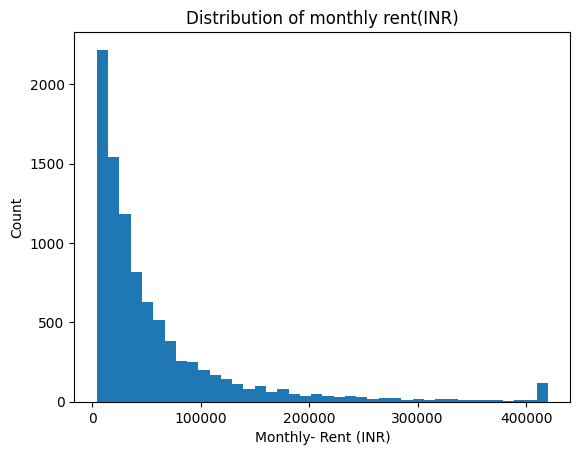

Skewness: 2.802


In [7]:
#EDA Steps ...
# target distribution : Monthly_rent_inr
target = "monthly_rent_inr"

plt.figure()
plt.hist(df[target], bins = 40)
plt.title("Distribution of monthly rent(INR)")
plt.xlabel("Monthly- Rent (INR)")
plt.ylabel("Count")
plt.show()

print("Skewness:", round(df[target].skew(), 3))

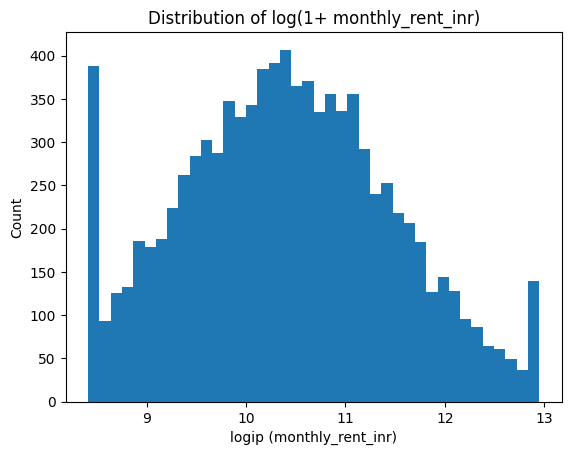

In [8]:
#Optional view: Log-transformed target (visual check only)
plt.figure()
plt.hist(np.log1p (df [target]), bins=40)
plt.title("Distribution of log(1+ monthly_rent_inr)")
plt.xlabel("logip (monthly_rent_inr)")
plt.ylabel("Count")
plt.show()

<Figure size 1200x500 with 0 Axes>

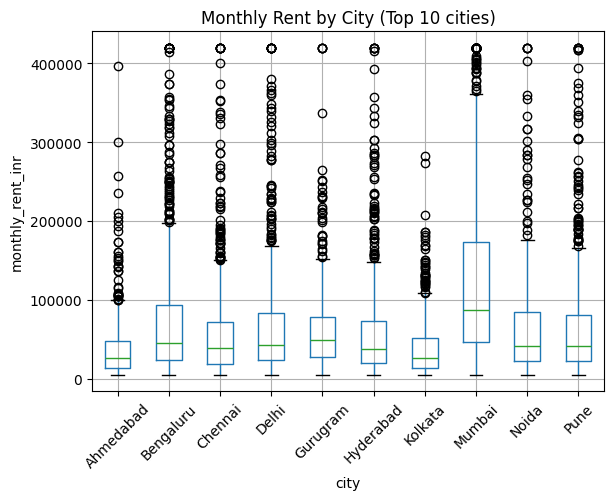

In [9]:
# Rent variation across cities (Top 10 cities by listing count)
top_cities = df["city"].value_counts().head(10).index
df_top = df[df["city"].isin(top_cities)].copy()

plt.figure(figsize=(12, 5))
df_top.boxplot(column=target, by="city", rot=45)
plt.title("Monthly Rent by City (Top 10 cities)")
plt.suptitle("")
plt.xlabel("city")
plt.ylabel("monthly_rent_inr")
plt.show()

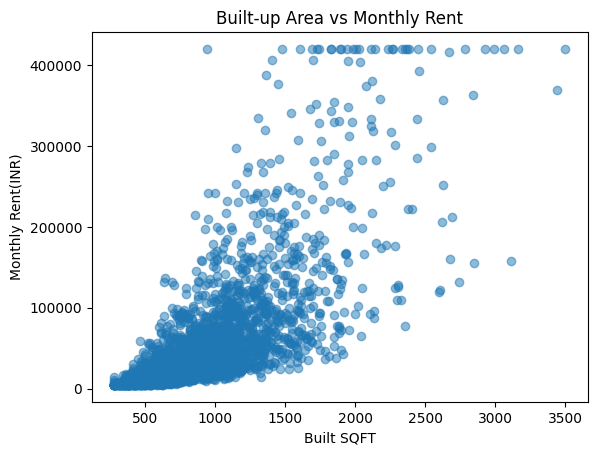

In [12]:
#Built-up area vs rent (scatter)
sample_df = df. sample(min (2500, len(df)), random_state= 42)
# keep it readable
plt.figure()
plt.scatter(sample_df ["builtup_sqft"], sample_df [target], alpha=0.5)
plt.title("Built-up Area vs Monthly Rent")
plt.xlabel("Built SQFT")
plt.ylabel("Monthly Rent(INR)")
plt.show()

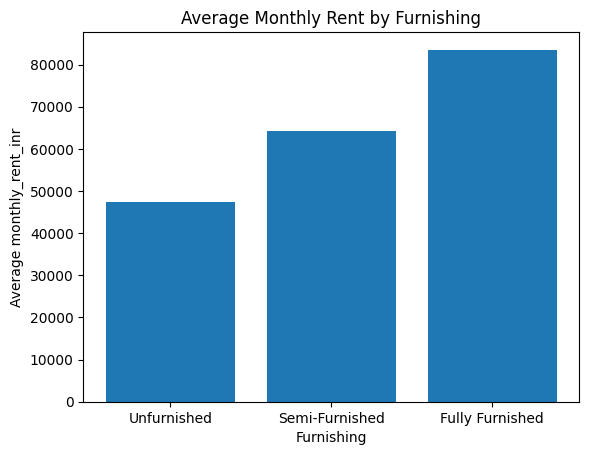

furnishing
Unfurnished        47315.067300
Semi-Furnished     64312.614155
Fully Furnished    83536.512346
Name: monthly_rent_inr, dtype: float64

In [13]:
# Average rent by furnishing status
avg_by_furnish = df.groupby("furnishing")[target].mean().sort_values()

plt.figure()
plt.bar(avg_by_furnish.index.astype(str), avg_by_furnish.values)
plt.title("Average Monthly Rent by Furnishing")
plt.xlabel("Furnishing")
plt.ylabel("Average monthly_rent_inr")
plt.xticks(rotation=0)
plt.show()

avg_by_furnish


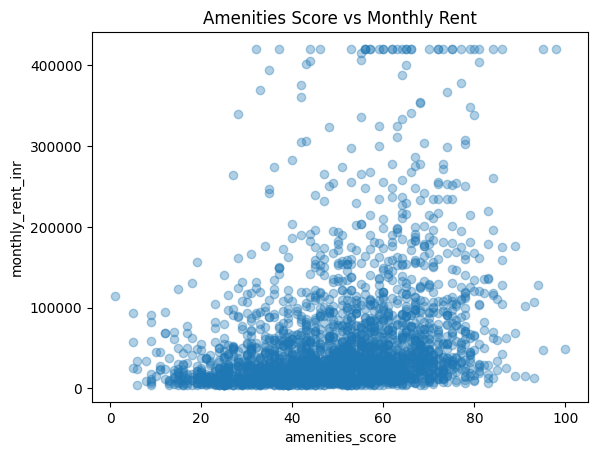

In [14]:
# Amenities score vs rent
sample_df = df[df["amenities_score"].notna()].sample(min(2500, df ["amenities_score"].notna().sum()), random_state=42)
plt.figure()
plt.scatter(sample_df["amenities_score"], sample_df[target], alpha=0.35)
plt.title("Amenities Score vs Monthly Rent")
plt.xlabel("amenities_score")
plt.ylabel("monthly_rent_inr")
plt.show()

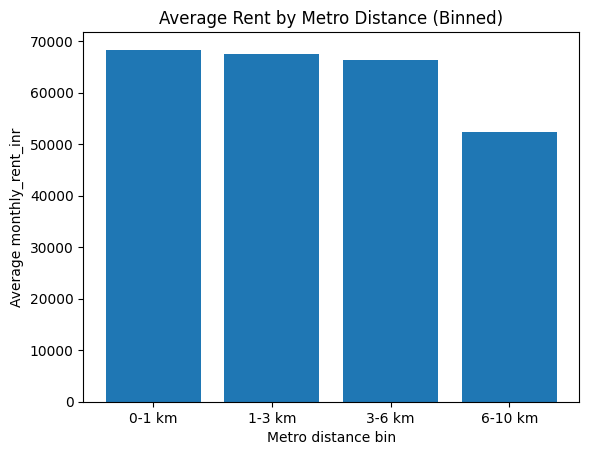

metro_bin
0-1 km     68331.485944
1-3 km     67475.493956
3-6 km     66364.016194
6-10 km    52294.315789
10+ km              NaN
Name: monthly_rent_inr, dtype: float64

In [15]:
# Rent vs metro distance (binned)
tmp = df[df["metro_distance_km"].notna()].copy()
bins = [0, 1, 3, 6, 10, 50]
labels = ["0-1 km", "1-3 km", "3-6 km", "6-10 km", "10+ km"]
tmp["metro_bin"] = pd.cut(tmp["metro_distance_km"], bins=bins, labels=labels, include_lowest=True)

avg_by_metro = tmp.groupby("metro_bin")[target].mean()

plt.figure()
plt.bar(avg_by_metro.index.astype(str), avg_by_metro.values)
plt.title("Average Rent by Metro Distance (Binned)")
plt.xlabel("Metro distance bin")
plt.ylabel("Average monthly_rent_inr")
plt.xticks(rotation=0)
plt.show()

avg_by_metro

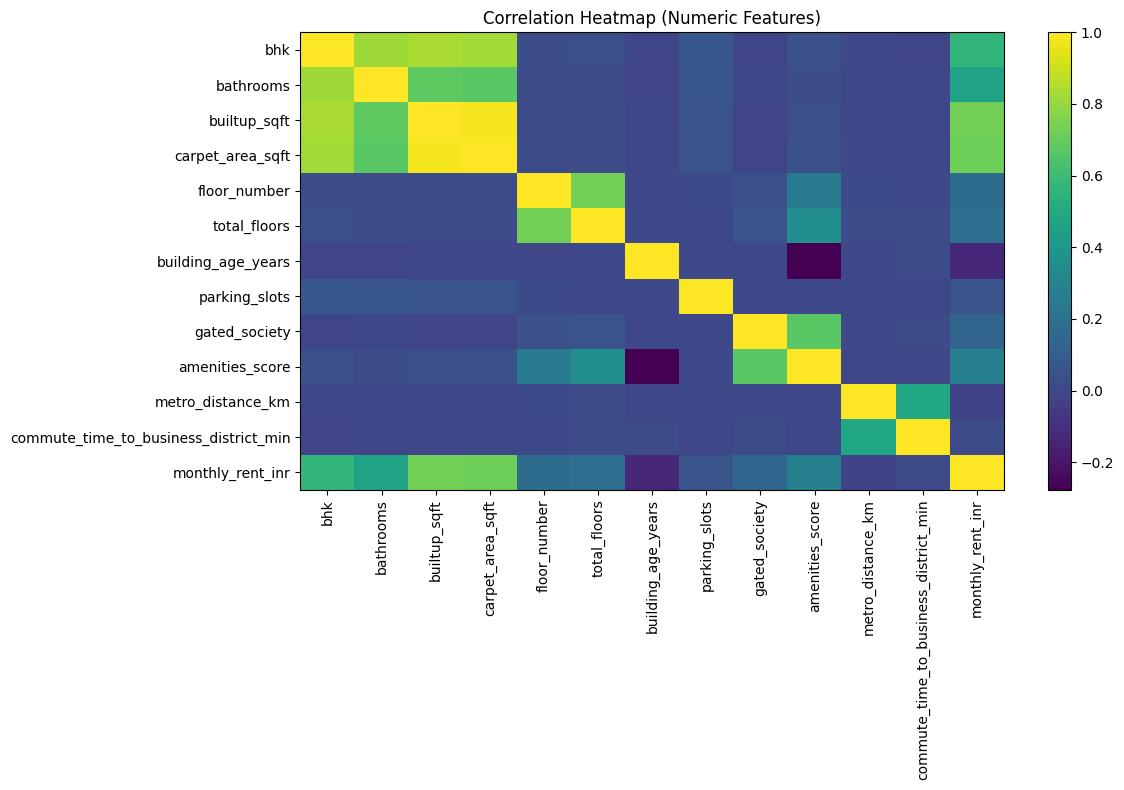

In [16]:
# Correlation heatmap (numeric features only) - high level view
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


In [17]:
target = "monthly_rent_inr"

X = df.drop(columns=[target])
y = df[target].astype(float)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (7440, 19) | Test shape: (1860, 19)


In [18]:
# Identify numeric and categorical columns
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing for numeric columns: impute + scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical columns: impute + one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


Numeric features: ['bhk', 'bathrooms', 'builtup_sqft', 'carpet_area_sqft', 'floor_number', 'total_floors', 'building_age_years', 'parking_slots', 'gated_society', 'amenities_score', 'metro_distance_km', 'commute_time_to_business_district_min']
Categorical features: ['listing_id', 'city', 'locality', 'property_type', 'furnishing', 'maintenance_included', 'power_backup']


In [19]:
#We will evaluate every model using:
#R² (explained variance)
#Adjusted R² (penalizes unnecessary features)
#MAE (average absolute error)
#RMSE (penalizes large errors more strongly)
def adjusted_r2(r2, n, p):
#n number of samples, p number of features 
    return 1 + - (1 - r2) * (n - 1) / (n - p - 1)


def regression_metrics(y_true, y_pred, p):
    r2 = r2_score(y_true, y_pred)
    adj = adjusted_r2(r2, n=len(y_true), p=p)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"R2": r2, "Adjusted_R2": adj, "MAE": mae, "RMSE": rmse}

In [20]:
# Baseline: Linear Regression using numeric features only
X_num = df[numeric_features].copy()
y_all = df[target].astype(float)

Xn_train, Xn_test, yn_train, yn_test = train_test_split(X_num, y_all, test_size=0.2, random_state=42)

baseline_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

baseline_pipe.fit(Xn_train, yn_train)
pred_baseline = baseline_pipe.predict(Xn_test)

# p = number of numeric features
baseline_results = regression_metrics(yn_test, pred_baseline, p=Xn_test.shape[1])
baseline_results


{'R2': 0.6037299238839795,
 'Adjusted_R2': 0.6011553484029875,
 'MAE': 29264.644288010397,
 'RMSE': np.float64(45536.19521363172)}

In [ ]:
# Prepare data for ANN (One Hot + Scaling)...
# Fit on training data, transform train/test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# ColumnTransformer may output sparse matrices (because of one-hot encoding).
# Keras generally works best with dense arrays, so convert when needed.
if hasattr(X_train_processed, "toarray"):# This is to check whether x-train-processed is array or not if not it comes down if it right then it will come out loop.
    X_train_processed = X_train_processed.toarray()
    X_test_processed  = X_test_processed.toarray()

# Ensure float32 for TensorFlow
X_train_processed = X_train_processed.astype("float32")
X_test_processed  = X_test_processed.astype("float32")

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape :", X_test_processed.shape)

# p = number of processed features after one-hot
p_processed = X_test_processed.shape[1]
print(p_processed)


Processed train shape: (7440, 7724)
Processed test shape : (1860, 7724)
7724


In [22]:
#Model -2 Simple ANN 10 Epochs ...

# ------------------------------------
# Simple ANN Model
# ------------------------------------
model_ann = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_processed.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1) # regression output
])

model_ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

model_ann.summary()

history_ann = model_ann.fit(
    X_train_processed, y_train.values,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       494,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 496,513 (1.89 MB)

 Trainable params: 496,513 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 8854035456.0000 - val_loss: 8486437888.0000
Epoch 2/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8679105536.0000 - val_loss: 8124209152.0000
Epoch 3/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8024513024.0000 - val_loss: 7181220864.0000
Epoch 4/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6768297984.0000 - val_loss: 5728332800.0000
Epoch 5/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5187989504.0000 - val_loss: 4188941056.0000
Epoch 6/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3793963008.0000 - val_loss: 3073965824.0000
Epoch 7/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2937050368.0000 - val_loss: 2499737600.0000
Epoch 8/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2526206208.0000 - val_loss: 2238019072.0000
Epoch 9/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2307595008.0000 - val_loss: 2073359232.0000
Epoch 10/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 215

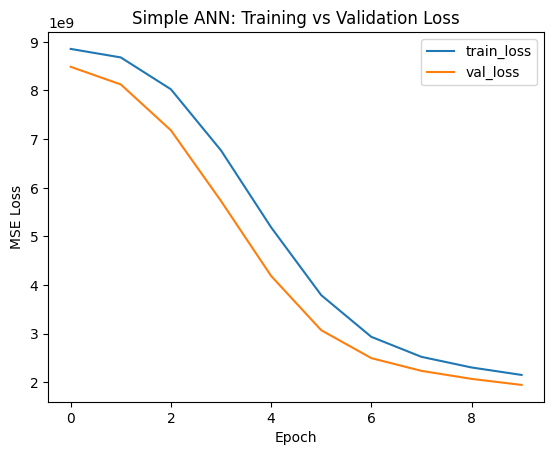

In [23]:
# Plot training vs validation loss (Simple ANN)
plt.figure()
plt.plot(history_ann.history["loss"], label="train_loss")
plt.plot(history_ann.history["val_loss"], label="val_loss")
plt.title("Simple ANN: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [25]:
#Predictions evaluation (Simple ANN)
pred_ann = model_ann.predict(X_test_processed).reshape(-1)

ann_results = regression_metrics(y_test, pred_ann, p=p_processed)
ann_results

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


{'R2': 0.6084357658160028,
 'Adjusted_R2': 1.12411217584792,
 'MAE': 28354.780615172847,
 'RMSE': np.float64(45265.00879847683)}

In [ ]:
# Model - 3 Deep ANN ( More layers + More Epochs)
# Deep Neural Network 